# PolyGraphPy: A unified Python framework for atomistic simulation and machine learning-driven polymer design

This notebook demonstrates the workflow and capabilities of **PolyGraphPy**, a modular Python framework for atomistic simulation, molecular property prediction, and property-guided polymer generation. The analyses presented here replicate the results reported in the manuscript.

## 1. Environment Setup

We first import the required Python packages, including PyTorch, PyTorch Geometric, RDKit, DFTB+, and standard data analysis libraries.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem

plt.rcParams.update({
    "text.usetex": False,            
    "mathtext.fontset": "cm",        
    "font.family": "serif",          
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
```

## 2. Load and Inspect Monomer Dataset
We load the acrylate monomer dataset (9,626 entries) used in this study. We focus on key molecular descriptors such as molecular weight, XLogP, polar surface area, complexity, number of rotatable bonds, and heavy atom count.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem

plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",   
    "font.family": "serif",      
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# Load original acrylate monomer dataset
df_original = pd.read_csv('../polygraphpy/data/original_dataset.csv')

# Select relevant columns and rename SMILES column
df_original = df_original[['smiles', 'mw', 'xlogp', 'polararea', 'complexity', 'rotbonds', 'heavycnt']]
df_original = df_original.rename(columns={'smiles': 'smiles_A'})

# Display dataset size
print(f"Number of monomers in the dataset: {len(df_original)}")


Number of monomers in the dataset: 9626


## 3. Distribution of Molecular Descriptors

To better understand the acrylate monomer dataset, we visualize the distributions of key molecular descriptors using histograms. These descriptors provide insight into the chemical space and structural diversity of the monomers.

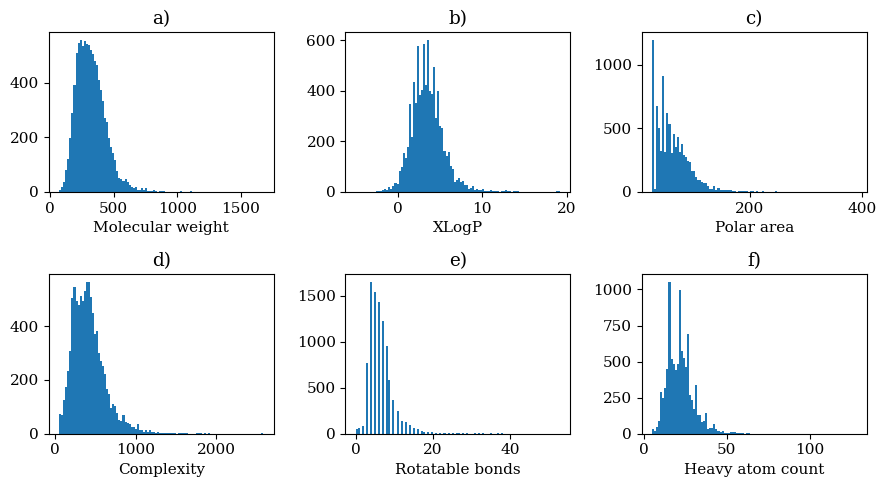

In [6]:
# Set up figure
fig, axes = plt.subplots(2, 3, figsize=(9, 5))
axes = axes.flatten()  # Flatten for easy iteration

# Define descriptors and labels
descriptors = ['mw', 'xlogp', 'polararea', 'complexity', 'rotbonds', 'heavycnt']
labels = ['Molecular weight', 'XLogP', 'Polar area', 'Complexity', 'Rotatable bonds', 'Heavy atom count']
titles = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']

# Plot histograms
for ax, desc, label, title in zip(axes, descriptors, labels, titles):
    ax.hist(df_original[desc], bins=100)
    ax.set_xlabel(label)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig('../figures/Figure_12.pdf')

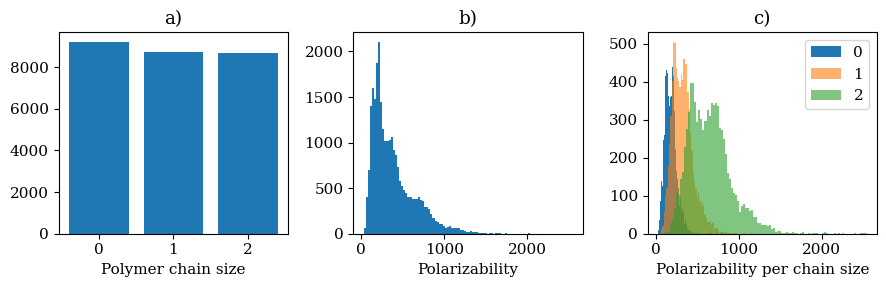

In [7]:
df_homopolymer = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

df_chain_size = df_homopolymer.groupby('chain_size').count().reset_index()

fig = plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.bar(df_chain_size['chain_size'], df_chain_size['id_A'])
plt.xlabel('Polymer chain size')
plt.title('a)')

plt.subplot(1,3,2)
plt.hist(df_homopolymer['static_polarizability'], bins=100)
plt.xlabel('Polarizability')
plt.title('b)')

plt.subplot(1,3,3)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 0]['static_polarizability'], bins=100, alpha=1)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 1]['static_polarizability'], bins=100, alpha=0.6)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 2]['static_polarizability'], bins=100, alpha=0.6)
plt.xlabel('Polarizability per chain size')
plt.legend(['0', '1', '2'])
plt.title('c)')

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_13.pdf')

## 4. Static Polarizability of Monomers and Homopolymers

The atomistic simulation module of **PolyGraphPy** computes quantum mechanical properties using DFTB+, including the **static polarizability** of monomers and short polymer chains.  

Here, we load the dataset containing monomer/homopolymer (chain sizes 0, 1 and 2) and copolymer polarizabilities. The first contains 26,582 entries, the latter 41,835 contains with the following key columns:  

- `id_A` / `id_B`: ID of each monomer
- `smiles_A` / `smiles_B`: SMILES representation of monomers  
- `chain_size`: Length of the polymer chain  
- `static_polarizability`: Computed polarizability in atomic units  
- `type`: Indicates whether the entry is a monomer, homopolymer, or copolymer  

Explanation:
- Missing values in id_B and smiles_B indicate entries corresponding to monomers or homopolymers.
- These datasets are used to analyze property distributions and validate GNN predictions.

In [ ]:
# Load polarizability data for monomers/homopolymers and copolymers
df_homopolymer = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/polarizability_data_copoly.csv')

### 4.1 Visualizing Polarizability Distributions
We visualize the distribution of static polarizabilities using histograms and a boxplot. To avoid outliers affecting visualization, we exclude the top 15 sorted values.

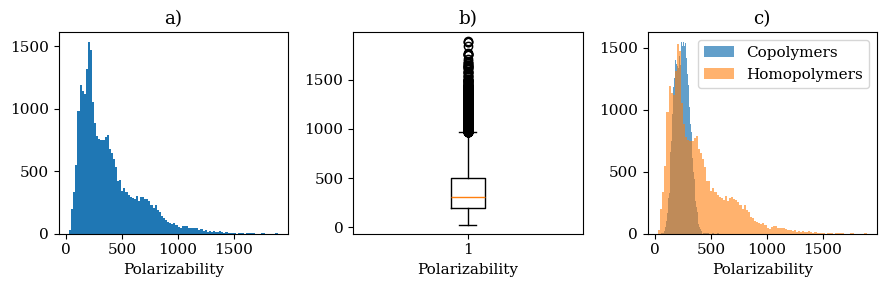

In [17]:
# Prepare figure
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# Subplot (a): Histogram of copolymer polarizabilities
axes[0].hist(df_homopolymer['static_polarizability'].sort_values()[:-15], bins=100)
axes[0].set_xlabel('Polarizability')
axes[0].set_title('a)')

# Subplot (b): Boxplot of copolymer polarizabilities
axes[1].boxplot(df_homopolymer['static_polarizability'].sort_values()[:-15])
axes[1].set_xlabel('Polarizability')
axes[1].set_title('b)')

# Subplot (c): Comparison histogram between copolymers and homopolymers
axes[2].hist(df_copolymer['static_polarizability'].sort_values()[:-15], bins=100, alpha=0.7, label='Copolymers')
axes[2].hist(df_homopolymer['static_polarizability'].sort_values()[:-15], bins=100, alpha=0.6, label='Homopolymers')
axes[2].set_xlabel('Polarizability')
axes[2].set_title('c)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Save figure
fig.savefig('../figures/Figure_14.pdf')


## 5. GNN Training Statistics

We trained a **GNN** model to predict static polarizabilities for monomers, homopolymers, and copolymers. Here, we visualize the **training and validation losses** over epochs for both datasets.

Explanation:
- The plots show mean squared error (MSE) loss for training and validation datasets over each epoch.
- Subplot (a) represents monomers and homopolymers; subplot (b) represents copolymers.

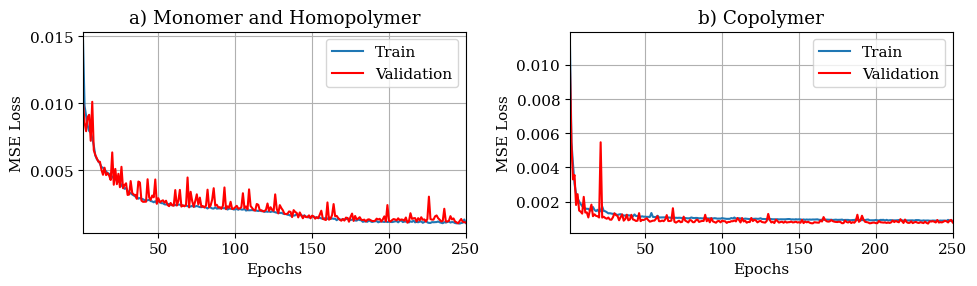

In [20]:
# Load training statistics
df_training_homopolymer = pd.read_csv('../polygraphpy/data/gnn_output/training_statistics.csv')
df_training_copolymer = pd.read_csv('../polygraphpy/data/gnn_output_copoly/training_statistics_copoly.csv')

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Subplot (a): Monomer and homopolymer training
axes[0].plot(df_training_homopolymer['epoch'] + 1, df_training_homopolymer['train_loss'], label='Train')
axes[0].plot(df_training_homopolymer['epoch'] + 1, df_training_homopolymer['val_loss'], 'r', label='Validation')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlim([1, df_training_homopolymer['epoch'].max() + 1])
axes[0].grid(True)
axes[0].legend()

# Subplot (b): Copolymer training
axes[1].plot(df_training_copolymer['epoch'] + 1, df_training_copolymer['train_loss'], label='Train')
axes[1].plot(df_training_copolymer['epoch'] + 1, df_training_copolymer['val_loss'], 'r', label='Validation')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title('b) Copolymer')
axes[1].set_xlim([1, df_training_copolymer['epoch'].max() + 1])
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_15.pdf")

## 6. GNN Predictions vs. Ground Truth

We evaluate the performance of the GNN model by comparing predicted static polarizabilities against the original ground truth values for both monomers/homopolymers and copolymers.  

Since the model outputs were scaled during training using MinMaxScaler, we first **rescale predictions and ground truths** back to the original polarizability range.

Explanation:
- Each point represents one molecule (monomer, homopolymer, or copolymer).
- The red line represents perfect prediction (y = x). Points near this line indicate accurate predictions.
- Scatter density and deviation from the line provide a visual estimate of model performance.
- Rescaling ensures predictions are directly comparable to computed polarizabilities.
- These plots demonstrate that the GNN effectively captures the quantum mechanical property trends across both datasets.


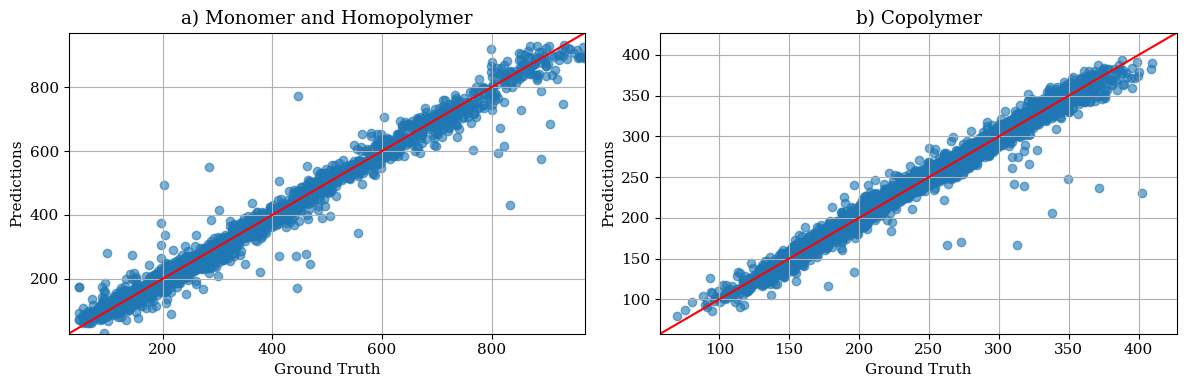

In [22]:
# Load prediction and ground truth datasets
df_pred_homopoly = pd.read_csv('../polygraphpy/data/gnn_output/df_results.csv')
df_original_homopoly = pd.read_csv('../polygraphpy/data/gnn_output/scaled_output.csv')
df_pred_copoly = pd.read_csv('../polygraphpy/data/gnn_output_copoly/df_results.csv')
df_original_copoly = pd.read_csv('../polygraphpy/data/gnn_output_copoly/scaled_output_copoly.csv')

# Retrieve original min and max for rescaling
min_max_homo = (df_original_homopoly['static_polarizability_original'].min(),
                df_original_homopoly['static_polarizability_original'].max())
min_max_copoly = (df_original_copoly['static_polarizability_original'].min(),
                  df_original_copoly['static_polarizability_original'].max())

# Rescale predictions and ground truths
df_pred_homopoly['y_original'] = df_pred_homopoly['y'] * (min_max_homo[1] - min_max_homo[0]) + min_max_homo[0]
df_pred_homopoly['pred_original'] = df_pred_homopoly['pred'] * (min_max_homo[1] - min_max_homo[0]) + min_max_homo[0]

df_pred_copoly['y_original'] = df_pred_copoly['y'] * (min_max_copoly[1] - min_max_copoly[0]) + min_max_copoly[0]
df_pred_copoly['pred_original'] = df_pred_copoly['pred'] * (min_max_copoly[1] - min_max_copoly[0]) + min_max_copoly[0]

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Subplot (a): Monomer and homopolymer
axes[0].scatter(df_pred_homopoly['y_original'], df_pred_homopoly['pred_original'], alpha=0.6)
axes[0].plot([min_max_homo[0], min_max_homo[1]], [min_max_homo[0], min_max_homo[1]], 'r')
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Predictions")
axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlim(min_max_homo)
axes[0].set_ylim(min_max_homo)
axes[0].grid(True)

# Subplot (b): Copolymer
axes[1].scatter(df_pred_copoly['y_original'], df_pred_copoly['pred_original'], alpha=0.6)
axes[1].plot([min_max_copoly[0], min_max_copoly[1]], [min_max_copoly[0], min_max_copoly[1]], 'r')
axes[1].set_xlabel("Ground Truth")
axes[1].set_ylabel("Predictions")
axes[1].set_title('b) Copolymer')
axes[1].set_xlim(min_max_copoly)
axes[1].set_ylim(min_max_copoly)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_16.pdf")

## 7. Uncertainty Estimation Using Monte Carlo Dropout

To quantify prediction uncertainty, we perform **Monte Carlo Dropout** on the validation set. This involves running the GNN model multiple times with dropout enabled during inference, producing a distribution of predictions for each molecule.  

Here, we visualize the **ensemble of predictions** for both monomers/homopolymers and copolymers.

Explanation:
- Each black line represents a single Monte Carlo dropout run, showing variability in predictions.
- The blue dotted line shows the mean of all 100 runs, providing a stable estimate of the predicted polarizability.
- The red line is the ground truth. Close alignment between the mean and ground truth indicates good predictive performance.
- Variability among the black lines reflects the model’s uncertainty in its predictions.
- Using Monte Carlo Dropout allows estimation of epistemic uncertainty in molecular property predictions, useful for guiding generative design or identifying high-confidence predictions.


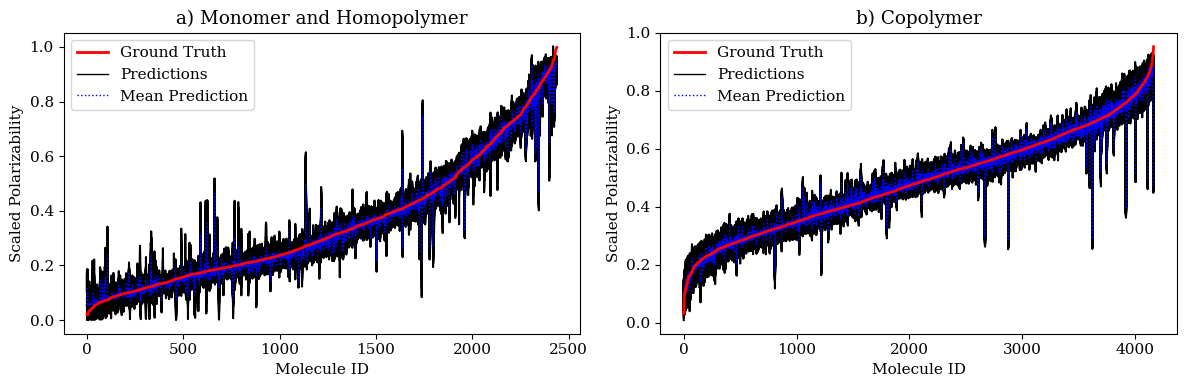

In [49]:
# Load Monte Carlo Dropout results
df_homopolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_homopolymer.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_copolymer.csv')

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Subplot (a): Monomer and homopolymer
for i in range(100):
    axes[0].plot(df_homopolymer.index, df_homopolymer[f'run_{i}'], color='k')

line_pred, = axes[0].plot(df_homopolymer.index, df_homopolymer['run_0'], 'k', linewidth=1)
line_mean, = axes[0].plot(df_homopolymer.index, df_homopolymer.drop(columns='y').mean(axis=1), ':b', linewidth=1)
line_gt, = axes[0].plot(df_homopolymer.index, df_homopolymer['y'], 'r', linewidth=2)

axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlabel("Molecule ID")
axes[0].set_ylabel("Scaled Polarizability")
axes[0].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[0].legend([line_gt, line_pred, line_mean], ['Ground Truth', 'Predictions', 'Mean Prediction'])

# Subplot (b): Copolymer
for i in range(100):
    axes[1].plot(df_copolymer.index, df_copolymer[f'run_{i}'], color='k')

line_pred, = axes[1].plot(df_copolymer.index, df_copolymer['run_0'], 'k', linewidth=1)
line_mean, = axes[1].plot(df_copolymer.index, df_copolymer.drop(columns='y').mean(axis=1), ':b', linewidth=1)
line_gt, = axes[1].plot(df_copolymer.index, df_copolymer['y'], 'r', linewidth=2)

axes[1].set_title('b) Copolymer')
axes[1].set_xlabel("Molecule ID")
axes[1].set_ylabel("Scaled Polarizability")
axes[1].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1].legend([line_gt, line_pred, line_mean], ['Ground Truth', 'Predictions', 'Mean Prediction'])

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_17.pdf")

## 8. Molecular Prediction Uncertainty: Standard Deviation

To quantify the **uncertainty of predictions** for each molecule, we compute the **standard deviation** across the 100 Monte Carlo Dropout runs.  
Higher standard deviation indicates higher model uncertainty for a given molecule.

Explanation:
- Each point represents the standard deviation of 100 Monte Carlo Dropout runs for a single molecule.
- Large deviations indicate molecules where the model is less confident.
- This plot complements the ensemble prediction visualization, providing a quantitative measure of uncertainty across the dataset.
- Such metrics are valuable for identifying molecules that may require additional atomistic simulations or experimental validation.


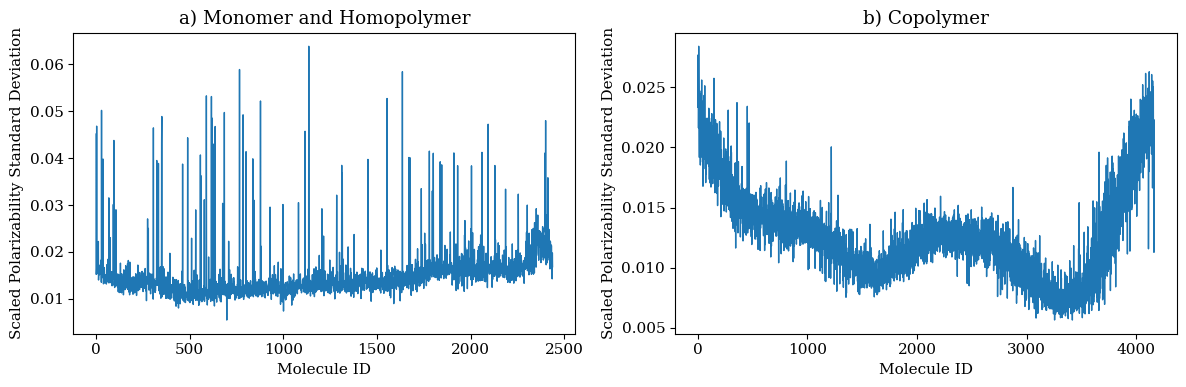

In [50]:
# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Subplot (a): Monomer and homopolymer
axes[0].plot(df_homopolymer.index, df_homopolymer.drop(columns='y').std(axis=1), linewidth=1)
axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlabel("Molecule ID")
axes[0].set_ylabel("Scaled Polarizability Standard Deviation")

# Subplot (b): Copolymer
axes[1].plot(df_copolymer.index, df_copolymer.drop(columns='y').std(axis=1), linewidth=1)
axes[1].set_title('b) Copolymer')
axes[1].set_xlabel("Molecule ID")
axes[1].set_ylabel("Scaled Polarizability Standard Deviation")

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_18.pdf")

## 9. Distribution of Prediction Errors

To assess the accuracy and reliability of the GNN model, we analyze the distribution of prediction metrics across the validation set:

- **MAPE (%)**: Mean Absolute Percentage Error  
- **R²**: Coefficient of determination  
- **MSE (%)**: Mean Squared Error, scaled by 100 for visualization  

We visualize the distributions using **Kernel Density Estimation (KDE)** plots for both monomer/homopolymer and copolymer datasets.

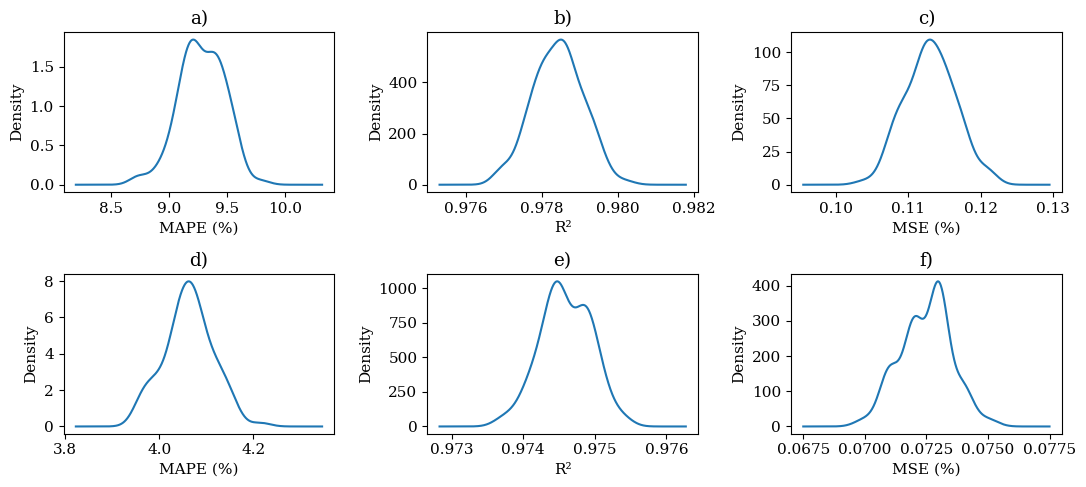

In [ ]:
# Load error metrics
df_homopolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_error_homopolymer.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_error_copolymer.csv')

# Scale MSE for visualization
df_homopolymer['mse'] = 100 * df_homopolymer['mse']
df_copolymer['mse'] = 100 * df_copolymer['mse']

# Set up figure
fig, axes = plt.subplots(2, 3, figsize=(11, 5))

# Monomer and homopolymer KDEs
df_homopolymer['mape'].plot.kde(ax=axes[0, 0])
axes[0, 0].set_xlabel('MAPE (%)'); axes[0, 0].set_title('a)')

df_homopolymer['r2'].plot.kde(ax=axes[0, 1])
axes[0, 1].set_xlabel('R²'); axes[0, 1].set_title('b)')

df_homopolymer['mse'].plot.kde(ax=axes[0, 2])
axes[0, 2].set_xlabel('MSE (%)'); axes[0, 2].set_title('c)')

# Copolymer KDEs
df_copolymer['mape'].plot.kde(ax=axes[1, 0])
axes[1, 0].set_xlabel('MAPE (%)'); axes[1, 0].set_title('d)')

df_copolymer['r2'].plot.kde(ax=axes[1, 1])
axes[1, 1].set_xlabel('R²'); axes[1, 1].set_title('e)')

df_copolymer['mse'].plot.kde(ax=axes[1, 2])
axes[1, 2].set_xlabel('MSE (%)'); axes[1, 2].set_title('f)')

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_19.pdf")

## 10. Analysis of Genetic Algorithm-Based Monomer Generation

To evaluate the performance of the **Genetic Algorithm (GA) generative model**, we analyze the predicted fitness values relative to their target polarizabilities.  
This analysis includes:

1. **Prediction vs. Ground Truth** for property-guided generation.  
2. **Fitness distributions** across different polarizabilities using a kernel density estimate (KDE) heatmap.

Explanation:
- Subplot (a): Scatter plot of GA-generated molecules’ predicted polarizabilities versus target polarizabilities with the original range. The red line indicates perfect agreement (y = x). High R² confirms the GA effectively optimizes molecules toward the target property.
- Subplot (b): KDE heatmap shows the distribution of fitness scores across polarizabilities. Ligther regions indicate higher density of solutions. This visualization highlights the property-guided exploration capability of the GA.
- Normalization and interpolation ensure smooth, interpretable visualization for publication.
- Together, these plots demonstrate both accuracy and diversity in the GA-generated molecular ensemble.

R² Score: 0.9888751113394822


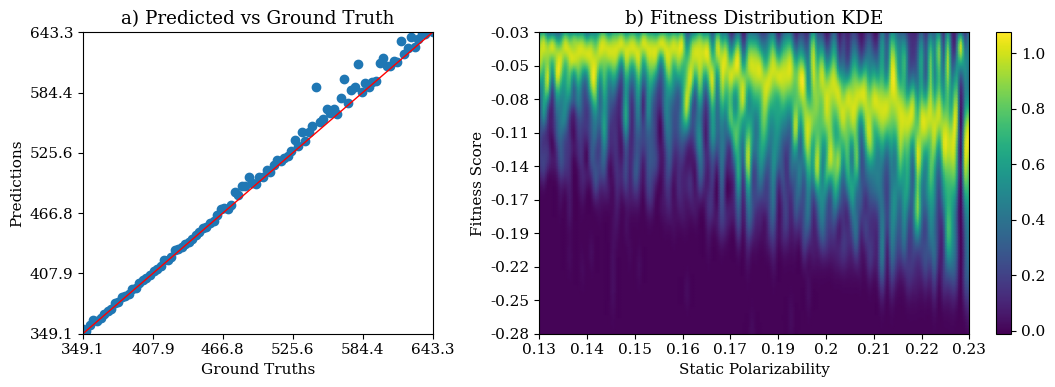

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from matplotlib import gridspec
from scipy.ndimage import zoom

# Load generated molecules and reference dataset
df = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

# Fit MinMaxScaler to original polarizabilities
scaler = MinMaxScaler().fit(df_original['static_polarizability'].values.reshape(-1,1))

# Compute best fitness per polarizability
best_fitness = df.groupby('static_polarizability')['fitness'].max()
targets_sorted = df["static_polarizability"].unique()

# Rescale predictions back to original polarizability range
pred = scaler.inverse_transform((targets_sorted - best_fitness).values.reshape(-1,1)).flatten()
targets_sorted = sorted(scaler.inverse_transform(targets_sorted.reshape(-1,1)).flatten())

# Create figure with two subplots
fig = plt.figure(figsize=(11, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.3, 2]) 
ax_scatter = plt.subplot(gs[0])
ax_heatmap = plt.subplot(gs[1])

# --- Subplot (a): Predicted vs. Target Polarizabilities ---
targets_sorted = np.array(targets_sorted)
ax_scatter.scatter(targets_sorted, pred)
ax_scatter.plot([targets_sorted.min(), targets_sorted.max()], [targets_sorted.min(), targets_sorted.max()], "r", linewidth=1)
ax_scatter.set_xlim([targets_sorted.min(), targets_sorted.max()])
ax_scatter.set_ylim([targets_sorted.min(), targets_sorted.max()])
ax_scatter.set_xticks(np.linspace(targets_sorted.min(), targets_sorted.max(), 6))
ax_scatter.set_yticks(np.linspace(targets_sorted.min(), targets_sorted.max(), 6))
ax_scatter.set_xlabel("Ground Truths")
ax_scatter.set_ylabel("Predictions")
ax_scatter.set_title("a) Predicted vs Ground Truth")

print("R² Score:", r2_score(targets_sorted, pred))

# --- Subplot (b): KDE Heatmap of Fitness Distributions ---
groups = df.groupby('static_polarizability')
polar_values = sorted(groups.groups.keys())
n_molecules = 100
fitness_values = np.linspace(df['fitness'].min(), df['fitness'].max(), n_molecules)
kde_matrix = np.zeros((n_molecules, len(polar_values)))

for i, polar in enumerate(polar_values):
    fitness = groups.get_group(polar)['fitness'].values
    kde = gaussian_kde(fitness, bw_method=0.3)
    kde_values = kde(fitness_values)
    kde_matrix[:, i] = kde_values / kde_values.max()  # Normalize

# Interpolate for smoother visualization
n = 200
zoom_factor = n / kde_matrix.shape[0] 
interpolated_matrix = zoom(kde_matrix, zoom=zoom_factor, order=3)

pcm = ax_heatmap.pcolormesh(interpolated_matrix, shading='gouraud')
ax_heatmap.set_xlabel('Static Polarizability')
ax_heatmap.set_ylabel('Fitness Score')
ax_heatmap.set_title('b) Fitness Distribution KDE')

# Configure ticks
n_x = min(len(interpolated_matrix), 10)
n_y = min(len(interpolated_matrix), 10)
fitness_values_interp = np.linspace(df['fitness'].min(), df['fitness'].max(), n)
polar_values_interp = np.linspace(min(polar_values), max(polar_values), n)
ax_heatmap.set_xticks(np.linspace(0, len(interpolated_matrix)-1, n_x))
ax_heatmap.set_xticklabels(np.round(polar_values_interp[::len(polar_values_interp)//n_x], 2))
ax_heatmap.set_yticks(np.linspace(0, len(interpolated_matrix)-1, n_y))
ax_heatmap.set_yticklabels(np.round(fitness_values_interp[::len(fitness_values_interp)//n_y], 2))

# Add colorbar
plt.colorbar(pcm, ax=ax_heatmap)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig("../figures/Figure_21.pdf", transparent=False)

## 11. Novelty Assessment of Generated Molecules

To evaluate the **novelty** of the generated molecules, we check which SMILES strings are **already present** in the original acrylate dataset.  
This provides insight into whether the generative model proposes **new chemical structures** or reproduces existing ones.

In [37]:
import pandas as pd

# Load GA-generated molecules and original dataset
df_generated = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

# Consider only monomers in original dataset (chain_size == 0)
df_original = df_original[df_original['chain_size'] == 0]

# Remove duplicates from generated molecules
df_unique = df_generated.drop_duplicates(subset='smiles')

# Compute fraction of generated molecules present in original dataset
fraction_present = len(df_unique[df_unique['smiles'].isin(df_original['smiles_A'])]) / len(df_unique)
novelty_fraction = 1 - fraction_present

print(f"Fraction of generated molecules that are novel: {novelty_fraction:.4f}")

Fraction of generated molecules that are novel: 0.9996


## 12. Analysis of GPT-Based Generative Model

We assess the GPT-based generative model in three aspects:

1. **Uniqueness** – fraction of generated SMILES that are distinct.  
2. **Novelty** – fraction of generated molecules not present in the original dataset.  
3. **Coverage** – polarizability values explored by the generated molecules.

Explanation:
- Uniqueness ensures the GPT model is not generating repeated molecules.
- Novelty measures how many generated molecules are new compared to the original dataset.
- Coverage examines the distribution of target polarizabilities to verify whether the model explores the desired property space comprehensively.
- Missing polarizability values indicate gaps in property-guided generation, which could guide further model refinement or sampling.


In [38]:
import pandas as pd
import numpy as np

# Load GPT-generated molecules and original dataset
df_generated = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

# Consider only monomers (chain_size == 0)
df_original = df_original[df_original['chain_size'] == 0]

# --- 1. Uniqueness ---
n_unique = len(df_generated['smiles_A'].drop_duplicates())
total_generated = len(df_generated['smiles_A'])
uniqueness_fraction = n_unique / total_generated
print(f"Fraction of unique generated molecules: {uniqueness_fraction:.4f}")

# --- 2. Novelty ---
novelty_fraction = 1 - df_generated['smiles_A'].drop_duplicates().isin(df_original['smiles_A']).sum() / n_unique
print(f"Fraction of novel molecules: {novelty_fraction:.4f}")

# --- 3. Polarizability Coverage ---
df_grouped = df_generated.groupby('static_polarizability').count()['smiles_A'].reset_index()
polarizability_series = pd.Series(np.linspace(0, 1, 200)).round(4)

# Identify polarizability bins not represented in generated dataset
missing_polarizabilities = polarizability_series[~polarizability_series.isin(df_generated['static_polarizability'].round(4))].values
print("Missing polarizabilities (not covered by generated molecules):", missing_polarizabilities)

Fraction of unique generated molecules: 1.0000
Fraction of novel molecules: 0.8630
Missing polarizabilities (not covered by generated molecules): [0.0804 0.5578 0.5678 0.6884 0.8191]


## 13. Visualization of GPT-Based Generation Accuracy

We evaluate the GPT-based model's ability to generate molecules with target polarizabilities by analyzing:

1. **Distribution of prediction errors** using KDE.  
2. **Best and interquartile range (IQR) of errors** per target polarizability.  
3. **Scatter plot of predicted vs. target polarizabilities** to assess accuracy.

Explanation:
- Subplot (a) shows the overall error distribution, highlighting typical deviations of GPT-generated molecules from target polarizabilities.
- Subplot (b) displays the best error and the interquartile range (IQR) per target, giving insight into consistency and reliability of generation.
- Subplot (c) presents a scatter plot of predicted versus ground truth polarizabilities; points close to the diagonal line indicate accurate generation.
- These plots collectively assess accuracy, consistency, and precision of the GPT-based generative model in property-guided molecular design.

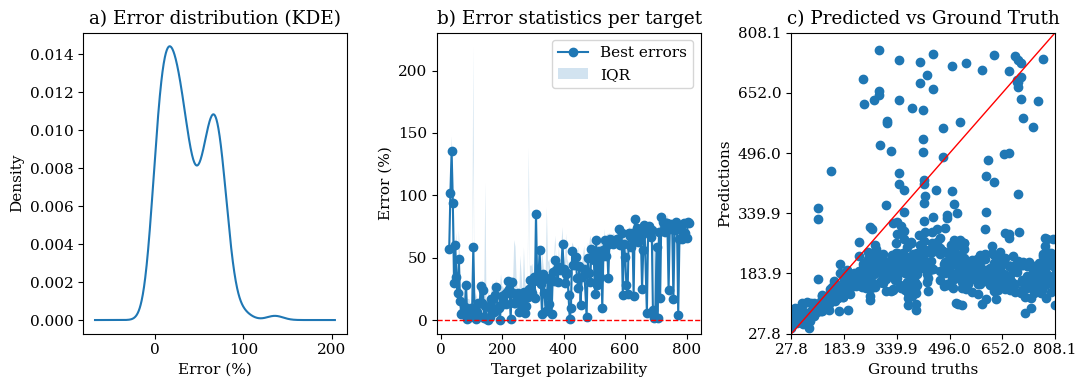

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load GPT-generated molecules
df = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')

# Convert absolute error to percentage
df['error'] = abs(100 * df['error'])

# Aggregate error statistics per target polarizability
df_grouped = df.groupby('static_polarizability_original').min()
best_fitness = df.groupby("static_polarizability_original")["error"].min()
q1 = df.groupby("static_polarizability_original")["error"].quantile(0.25)
q3 = df.groupby("static_polarizability_original")["error"].quantile(0.75)
targets_sorted = sorted(df["static_polarizability_original"].unique())

# Set up figure
fig = plt.figure(figsize=(11, 4))

# --- Subplot (a): KDE of errors ---
plt.subplot(1, 3, 1)
df_grouped['error'].plot.kde()
plt.xlabel('Error (%)')
plt.title('a) Error distribution (KDE)')

# --- Subplot (b): Best and IQR of errors per target polarizability ---
plt.subplot(1, 3, 2)
plt.plot(targets_sorted, best_fitness.loc[targets_sorted], marker="o", label="Best errors")
plt.fill_between(targets_sorted, q1.loc[targets_sorted], q3.loc[targets_sorted], alpha=0.2, label="IQR")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Target polarizability")
plt.ylabel("Error (%)")
plt.title("b) Error statistics per target")
plt.legend()

# --- Subplot (c): Predicted vs. Target Polarizabilities ---
targets_expanded = df["static_polarizability_original"]
pred = df["static_polarizability_pred_original"]

plt.subplot(1, 3, 3)
plt.scatter(targets_expanded, pred)
plt.plot([targets_expanded.min(), targets_expanded.max()], [targets_expanded.min(), targets_expanded.max()], "r", linewidth=1)
plt.xlim([targets_expanded.min(), targets_expanded.max()])
plt.ylim([targets_expanded.min(), targets_expanded.max()])
plt.xticks(np.linspace(targets_expanded.min(), targets_expanded.max(), 6))
plt.yticks(np.linspace(targets_expanded.min(), targets_expanded.max(), 6))
plt.xlabel("Ground truths")
plt.ylabel("Predictions")
plt.title("c) Predicted vs Ground Truth")

plt.tight_layout()
plt.show()

# Save figure
fig.savefig('../figures/Figure_22.pdf')

## 14. Analysis of Top 200 GPT-Generated Candidates

We focus on the **best-performing 200 molecules** generated by the GPT model (based on lowest prediction error) to evaluate:

1. **Prediction accuracy** compared to ground truth polarizabilities.  
2. **Polarizability distribution** relative to the original dataset.

Explanation:
- Subplot (a) shows predicted versus ground truth polarizabilities for the top 200 candidates. Points close to the diagonal indicate high prediction accuracy.
- Subplot (b) compares the distribution of polarizabilities between the original dataset and the top 200 GPT-generated molecules, showing how well the best candidates cover the property space.
- Computing R² for all molecules and for the top 200 provides a quantitative measure of model performance, highlighting the quality of the top candidates for property-guided polymer design.

R² (all GPT-generated molecules): -1.0532


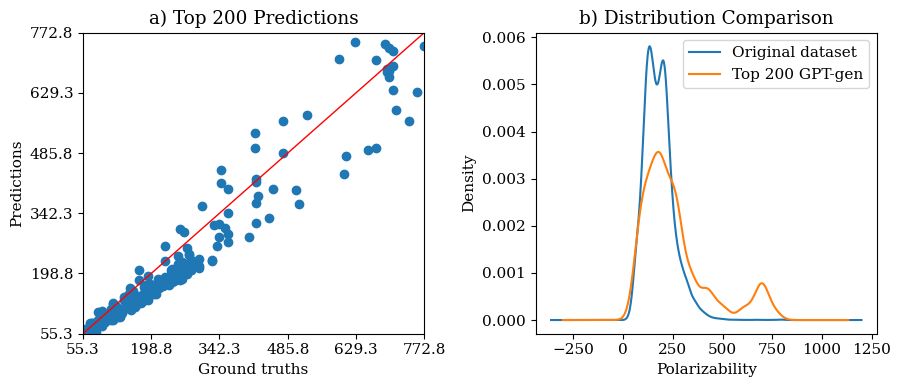

R² (Top 200 GPT-generated molecules): 0.8976


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Load GPT-generated molecules
df = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')

# Compute overall R² for all generated molecules
r2_all = r2_score(df['static_polarizability_original'], df['static_polarizability_pred_original'])
print(f"R² (all GPT-generated molecules): {r2_all:.4f}")

# Select top 200 candidates with lowest error (error <= 35%)
df_top200 = df[df['error'] <= 35].sort_values(by='error')[:200]

targets_expanded = df_top200["static_polarizability_original"]
pred = df_top200["static_polarizability_pred_original"]

# Plot prediction vs ground truth and distribution comparison
fig = plt.figure(figsize=(9, 4))

# --- Subplot (a): Predicted vs. Ground Truth ---
plt.subplot(1, 2, 1)
plt.scatter(targets_expanded, pred)
plt.plot([targets_expanded.min(), targets_expanded.max()],
         [targets_expanded.min(), targets_expanded.max()], "r", linewidth=1)
plt.xlim([targets_expanded.min(), targets_expanded.max()])
plt.ylim([targets_expanded.min(), targets_expanded.max()])
plt.xticks(np.linspace(targets_expanded.min(), targets_expanded.max(), 6))
plt.yticks(np.linspace(targets_expanded.min(), targets_expanded.max(), 6))
plt.xlabel("Ground truths")
plt.ylabel("Predictions")
plt.title("a) Top 200 Predictions")

# --- Subplot (b): Polarizability distribution ---
plt.subplot(1, 2, 2)
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_original = df_original[df_original['chain_size'] == 0]
df_original['static_polarizability'].plot.kde(bw_method=0.18)
df_top200['static_polarizability_original'].plot.kde(bw_method=0.18)
plt.xlabel('Polarizability')
plt.ylabel('Density')
plt.legend(['Original dataset', 'Top 200 GPT-gen'])
plt.title("b) Distribution Comparison")

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_23.pdf')

# Compute R² for top 200 candidates
r2_top200 = r2_score(df_top200['static_polarizability_original'], df_top200['static_polarizability_pred_original'])
print(f"R² (Top 200 GPT-generated molecules): {r2_top200:.4f}")